# Validate Somersalo scaling law

Here we show how we can compute multipactor thresholds measured for different reflection coefficient, and compare this evolution to Somersalo scaling law.

## Set up

In [1]:
from functools import partial

from multipac_testbench import TestCampaign
from multipac_testbench.data import config_path
from multipac_testbench.data.multipactor_tests import (
    test_140MHz_SWR4_11,
    test_140MHz_SWR3_12,
    test_140MHz_SWR2_13,
    test_140MHz_SWR1_14
)
from multipac_testbench.instruments import CurrentProbe, ForwardPower
from multipac_testbench.threshold import AveragedThresholdSet
from multipac_testbench.util.multipactor_detectors import quantity_is_above_threshold

tests = (test_140MHz_SWR4_11, test_140MHz_SWR3_12, test_140MHz_SWR2_13, test_140MHz_SWR1_14)
freqs = (140.0, 140.0, 140.0, 140.0)
swrs = (4.0, 3.0, 2.0, 1.0)

test_campaign =  TestCampaign.from_filepaths(
    tests,
    freqs,
    swrs,
    config_path,
    is_raw=True
)

[INFO    ] [loader.py           ] Applied trigger_policy = 'keep_all' on /home/placais/Documents/simulation/python/multipac_testbench/src/multipac_testbench/data/multipactor_tests/2025.06.20_140MHz-SWR4-11.csv
[ERROR   ] [factory.py          ] column_header = 'NI9205_E1' not present in provided file. Skipping associated instrument.
[INFO    ] [loader.py           ] Applied trigger_policy = 'keep_all' on /home/placais/Documents/simulation/python/multipac_testbench/src/multipac_testbench/data/multipactor_tests/2025.06.20_140MHz-SWR3-12.csv
[ERROR   ] [factory.py          ] column_header = 'NI9205_E1' not present in provided file. Skipping associated instrument.
[INFO    ] [loader.py           ] Applied trigger_policy = 'keep_all' on /home/placais/Documents/simulation/python/multipac_testbench/src/multipac_testbench/data/multipactor_tests/2025.06.20_140MHz-SWR2-13.csv
[ERROR   ] [factory.py          ] column_header = 'NI9205_E1' not present in provided file. Skipping associated instrument

/home/placais/Documents/simulation/python/multipac_testbench/src/multipac_testbench/util/physics.py:28: RuntimeWarning: invalid value encountered in sqrt
  reflection_coefficient = np.abs(np.sqrt(reflected_power / forward_power))
/home/placais/Documents/simulation/python/multipac_testbench/src/multipac_testbench/util/physics.py:28: RuntimeWarning: invalid value encountered in sqrt
  reflection_coefficient = np.abs(np.sqrt(reflected_power / forward_power))


## Calculate multipactor thresholds

In [2]:
current_multipactor_criterions = {'threshold': 14., 'minimum_number_of_points': 1}
current_multipac_detector = partial(quantity_is_above_threshold, **current_multipactor_criterions)

As Somersalo scaling law concerns power thresholds, we look for "global" multipactor criterions:

In [3]:
merged_thresholds = test_campaign.determine_thresholds(
    current_multipac_detector, CurrentProbe, threshold_reducer="any"
)
for threshold_set in merged_thresholds.values():
    threshold_set.remove_singularities()  # Avoid multipactor measured on a single point
    threshold_set.remove_detected_by("NI9205_MP8l")  # Avoid accounting for same MP twice (E8 is in front of E4)

[WARNING ] [threshold.py        ] User should manually trim exceedent powers in order to avoid flat minima at the end of the test.
[WARNING ] [threshold.py        ] User should manually trim exceedent powers in order to avoid flat minima at the end of the test.
[WARNING ] [threshold.py        ] User should manually trim exceedent powers in order to avoid flat minima at the end of the test.
[WARNING ] [threshold.py        ] User should manually trim exceedent powers in order to avoid flat minima at the end of the test.
[INFO    ] [threshold_set.py    ] Removed the 0 thresholds detected by NI9205_MP8l
[INFO    ] [threshold_set.py    ] Removed the 0 thresholds detected by NI9205_MP8l
[INFO    ] [threshold_set.py    ] Removed the 0 thresholds detected by NI9205_MP8l
[INFO    ] [threshold_set.py    ] Removed the 0 thresholds detected by NI9205_MP8l


We average the "global" multipactor thresholds measured during the last power step:

In [4]:
averaged = {
    test: AveragedThresholdSet.from_threshold_set(
        merged, predicate=lambda x: x.sample_index >= 360
    )
    for test, merged in merged_thresholds.items()
}

## Check Somersalo scaling law

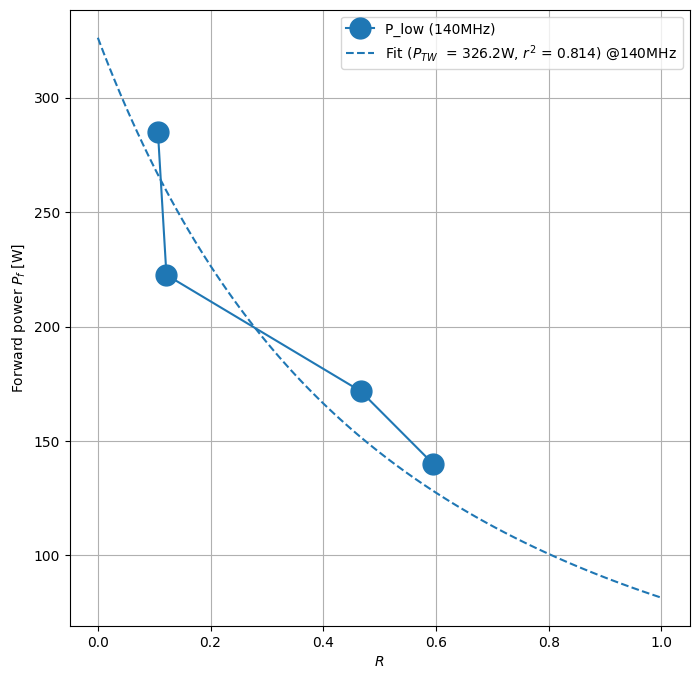

In [5]:
_ = test_campaign.check_somersalo_scaling_law(
    averaged,
    figsize=(8, 8),
)